In [1]:
import xarray as xr
from daz_iono import *
from lics_unwrap import *
from scipy.constants import speed_of_light
import numpy as np
from scipy.interpolate import griddata
from LiCSAR_misc import *
import framecare as fc
from scipy.interpolate import interp1d

def get_inc_frame(frame, heading=False):
    '''will get the incidence angle 2d xr.datarray
    if heading==True: return also heading raster
    '''
    metadir = os.path.join(os.environ['LiCSAR_public'], str(int(frame[:3])), frame, 'metadata')
    Ufile = os.path.join(metadir, frame + '.geo.U.tif')
    U = load_tif2xr(Ufile)
    U = U.where(U != 0)
    inc = U.copy()
    inc.values = np.degrees(np.arccos(U.values))
    if heading:
        Efile = os.path.join(metadir, frame + '.geo.E.tif')
        Nfile = os.path.join(metadir, frame + '.geo.N.tif')
        E = load_tif2xr(Efile)
        N = load_tif2xr(Nfile)
        E = E.where(E != 0)
        N = N.where(N != 0)
        heading = N.copy(deep=True)
        heading.values = np.degrees(np.arctan2(E, N)) + 90
        return inc, heading
    else:
        return inc



setting pyproj data directory


In [2]:
frame='116A_05207_252525'
epoch='20160124'
# frame='021D_05266_252525'
epoch='20160130'
metadir = os.path.join('/gws/nopw/j04/nceo_geohazards_vol1/public/LiCSAR_products', str(int(frame[:3])), frame, 'metadata')
metafile = os.path.join(metadir,'metadata.txt')
#
center_time=grep1line('center_time',metafile).split('=')[1]
acqtime = pd.to_datetime(str(epoch) + 'T' + center_time)

In [3]:
tecxr=get_vtec_from_code(acqtime, lat=0, lon=0, return_fullxr = True)

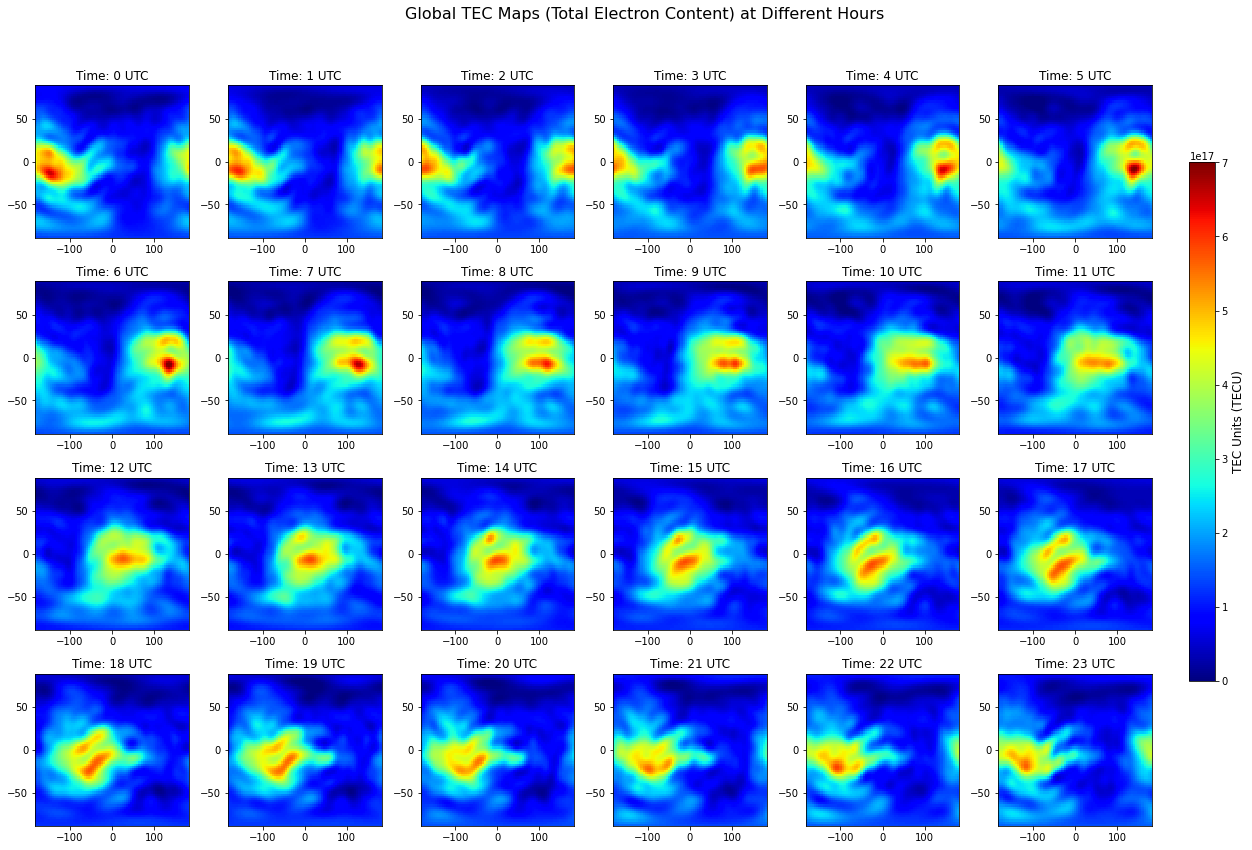

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Define the figure and axes (4 rows, 6 columns)
fig, axes = plt.subplots(4, 6, figsize=(18, 12))

# Adjust layout
fig.suptitle("Global TEC Maps (Total Electron Content) at Different Hours", fontsize=16)

# Determine vmin and vmax for a consistent color scale
vmin = tecxr.min().values
vmax = tecxr.max().values

# Loop through time steps and plot on subplots
for i, ax in enumerate(axes.flat):
    if i < len(tecxr.time):
        # Select the TEC map at time `i`
        tecxr_selected = tecxr.sel(time=tecxr.time[i])

        # Plot on the current axis with fixed vmin/vmax
        im = tecxr_selected.plot(ax=ax, cmap='jet', add_colorbar=False, vmin=0, vmax=7e17)
        
        # Set title as time step
        ax.set_title(f"Time: {int(tecxr.time[i].values)} UTC")
        
        # Remove axis labels for cleaner visualization
        ax.set_xlabel("")
        ax.set_ylabel("")
    else:
        ax.axis("off")  # Hide unused subplots if any

# Create a single colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)  # Assign the colorbar object
cbar.set_label("TEC Units (TECU)", fontsize=12)

# Set the colorbar range from 0 to 7e17
im.set_clim(0, 7e17)  # Correct method to apply limits

# Adjust spacing
plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # Leave space for the colorbar
plt.show()


In [5]:
####let's go to second step!

In [6]:
#This code is used the Ionex to xarray, but in JPLHR we already have .nc format!!

In [7]:
def download_code_data_JHR(acqtime, storedir = '/work/scratch-pw2/licsar/mnergiz/JPL_HR-GIM'):
    #lastrings = ['I', 'N']
    ffound = False
    if not ffound:
        filename = 'jpld'+ acqtime.strftime('%j') + '0.' + acqtime.strftime('%y')+'i.nc.gz' # TODO: check YMD
        url = 'https://sideshow.jpl.nasa.gov/pub/iono_daily/gim_for_research/jpld/' + str(acqtime.year) + '/' + filename
        fullpath = os.path.join(storedir, filename)
        ionix = fullpath[:-3]
        print(ionix)
        print(fullpath)
        if not os.path.exists(ionix):
            if not os.path.exists(fullpath):
                # download this
                try:
                    wgotfile = wget.download(url, out=storedir)
                except:
                    print('error during wget download')
                    ffound = False
            if os.path.exists(fullpath):
                ffound = True
        else:
            ffound = True
    if not ffound:
        print('no CODE layer found for '+filename)
        return False
    if not os.path.exists(ionix):
        rc = os.system('cd ' + storedir + '; 7za x ' + filename + ' >/dev/null 2>/dev/null; rm ' + fullpath)
    if not os.path.exists(ionix):
        print('ERROR: maybe you do not have 7za installed')
        return False
    return ionix

In [8]:
def get_vtec_from_code(acqtime, lat = 0, lon = 0, storedir = '/gws/nopw/j04/nceo_geohazards_vol1/code_iono', return_fullxr = False):
    """ Adapted from Reza Bordbari script, plus using functions from https://notebook.community/daniestevez/jupyter_notebooks/IONEX

    Args:
        acqtime (dt.datetime)
        lat (float)
        lon (float)
        storedir (str)
        return_fullxr (bool): if True, will return full TEC datacube
    """
    #D = acqtime.strftime('%Y%m%d')
    #ipp = np.array([lat,lon])
    # check if exists:
    fna = glob.glob(storedir+'/????'+ acqtime.strftime('%j') + '0.' + acqtime.strftime('%y')+ '?')
    if fna:
        ionix = os.path.join(storedir,fna[0])
    else:
        # download:
        ionix = download_code_data(acqtime, storedir)
    if not ionix:
        return False
    #else:
    #    rc=os.system('rm '+fullpath) # clean the .Z
    # prep 
    #hhmmss=acqtime.strftime('%H%M%S')
    # loading the TEC maps, thanks to https://notebook.community/daniestevez/jupyter_notebooks/IONEX (but improved towards xarray by ML B-)
    try:
        tecmaps = get_tecmaps(ionix)
    except:
        print('ERROR loading ionix file: '+ionix)
        return False
    try:
        interval = int(grep1line('INTERVAL',ionix).split()[0])
    except:
        print('ERROR, the ionix file '+ionix+' does not contain necessary keywords. Cancelling')
        return False
    timestep = interval/3600
    timecoords = np.arange(0.0,24.0+timestep,timestep)  # we expect start/end time being midnight, should be standard for all CODE files?
    lat_all = np.arange(87.5,-87.5-2.5,-2.5)
    lon_all = np.arange(-180.0,180.0+5,5.0)
    tecxr = xr.DataArray(data=tecmaps, dims=['time','lat','lon'],
                        coords=dict(time=timecoords, lon=lon_all, lat=lat_all) )
    # interpolate through the nan values
    tonan=9999
    tecxr.where(tecxr!=tonan)
    tecxr=tecxr.interpolate_na(dim="lon", method="linear", fill_value="extrapolate")
    tecxr = tecxr*1e+16 # from TECU
    if return_fullxr:
        return tecxr
    else:
        return get_vtec_from_tecxr(tecxr, acqtime, lat, lon)

In [9]:
def get_vtec_from_tecxr(tecxr, acqtime, lat, lon, rotate=True):
    '''Function to be used with tecxr (output from get_vtec_from_code) to get the tec for given coords'''
    h_time = float(acqtime.strftime('%H'))
    m_time = float(acqtime.strftime('%M'))
    s_time = float(acqtime.strftime('%S'))
    # given time in decimal format
    time_dec = h_time + (m_time/60) + (s_time / 3600)
    # ML: 2023/08, based on : https://github.com/insarlab/MintPy/blob/main/src/mintpy/objects/ionex.py
    # that is actually based on
    # Schaer, S., Gurtner, W., & Feltens, J. (1998). IONEX: The ionosphere map exchange format
    #         version 1.1. Paper presented at the Proceedings of the IGS AC workshop, Darmstadt, Germany.
    if rotate:
        # 3D interpolation with rotation as above reference
        try:
            htimes = tecxr.time.values
        except:
            htimes = np.array([float(tecxr.time)])  #in case of only one value
        pretime = int(htimes[htimes <= time_dec][-1])
        postime = int(htimes[htimes >= time_dec][0])
        #
        lon0 = lon + (time_dec - pretime) * 360. / 24.
        lon1 = lon + (time_dec - postime) * 360. / 24.
        #
        tec_val0 = float(tecxr.interp(time=pretime, lon=lon0, lat=lat, method='linear'))
        tec_val1 = float(tecxr.interp(time=postime, lon=lon1, lat=lat, method='linear'))
        #
        tec = ((postime - time_dec) / (postime - pretime) * tec_val0
                   + (time_dec - pretime) / (postime - pretime) * tec_val1)
    else:
        # previous attempt, but still too different from the S1_ETAD CODE outputs (that rotates the Earth towards the Sun..)
        tec = float(tecxr.interp(time=time_dec, lon=lon,lat=lat, method='cubic')) # should be better than linear, but maybe quadratic is more suitable?
    return tec

In [10]:
###
def parse_map(tecmap, exponent = -1):
    tecmap = re.split('.*END OF TEC MAP', tecmap)[0]
    return np.stack([np.fromstring(l, sep=' ') for l in re.split('.*LAT/LON1/LON2/DLON/H\\n',tecmap)[1:]])*10**exponent


def get_tecmaps(filename):
    try:
        exponent = int(grep1line('EXPONENT',filename).split()[0]) # this is exponent of the data
    except:
        print('WARNING, exponent not found in '+filename+'. Perhaps the file is corrupted?')
        exponent = -1
    with open(filename) as f:
        ionex = f.read()
        return [parse_map(t, exponent) for t in ionex.split('START OF TEC MAP')[1:]]

In [11]:
def download_code_data_JHR(acqtime, storedir = '/work/scratch-pw2/licsar/mnergiz/JPL_HR-GIM'):
    #lastrings = ['I', 'N']
    ffound = False
    if not ffound:
        filename = 'jpld'+ acqtime.strftime('%j') + '0.' + acqtime.strftime('%y')+'i.nc.gz' # TODO: check YMD
        url = 'https://sideshow.jpl.nasa.gov/pub/iono_daily/gim_for_research/jpld/' + str(acqtime.year) + '/' + filename
        fullpath = os.path.join(storedir, filename)
        ionix = fullpath[:-3]
        if not os.path.exists(ionix):
            if not os.path.exists(fullpath):
                # download this
                try:
                    wgotfile = wget.download(url, out=storedir)
                except:
                    print('error during wget download')
                    ffound = False
            if os.path.exists(fullpath):
                ffound = True
        else:
            ffound = True
    if not ffound:
        print('no CODE layer found for '+filename)
        return False
    if not os.path.exists(ionix):
        rc = os.system('cd ' + storedir + '; 7za x ' + filename + ' >/dev/null 2>/dev/null; rm ' + fullpath)
    if not os.path.exists(ionix):
        print('ERROR: maybe you do not have 7za installed')
        return False
    return ionix
ionix_JHR = download_code_data_JHR(acqtime)
ionix = download_code_data(acqtime)

In [31]:
tecxr=get_vtec_from_code(acqtime, lat=0, lon=0, return_fullxr = True)

In [13]:
ionix_JHR = download_code_data_JHR(acqtime)

In [14]:
def download_code_data(acqtime, storedir = '/gws/nopw/j04/nceo_geohazards_vol1/code_iono'):
    """Downloads Ionospheric TEC data from JPL or CODE."""
    ffound = False
    if not ffound:
        filename = 'jpld'+ acqtime.strftime('%j') + '0.' + acqtime.strftime('%y')+'i.nc.gz' # TODO: check YMD
        url = 'https://sideshow.jpl.nasa.gov/pub/iono_daily/gim_for_research/jpld/' + str(acqtime.year) + '/' + filename
        fullpath = os.path.join(storedir, filename)
        ionix = fullpath[:-3]
        if not os.path.exists(ionix):
            if not os.path.exists(fullpath):
                # download this
                try:
                    wget.download(url, out=storedir)
                    ffound = True 
                except:
                    #print('jpl-hr not exist')
                    ffound = False
            if os.path.exists(fullpath):
                ffound = True
        else:
            ffound = True
    ###if JPL HR-GIM is not available, then try to download CODE data. After, 2024-08-01 we need CODE data. 
    if not ffound:  
        instrings = ['CODG', 'CGIM']
        #lastrings = ['I', 'N']
        for instr in instrings:
            #for lastr in lastrings:
            filename = instr + acqtime.strftime('%j') + '0.' + acqtime.strftime('%y') + 'I.Z'
            url = 'http://ftp.aiub.unibe.ch/CODE/' + acqtime.strftime('%Y') + '/' + filename
            fullpath = os.path.join(storedir, filename)
            ionix = fullpath[:-2]
            if not os.path.exists(ionix):
                if not os.path.exists(fullpath):
                    # download this
                    try:
                        wget.download(url, out=storedir)
                        ffound = True 
                    except:
                        #print('code-oldname not exists')
                        ffound = False
                if os.path.exists(fullpath):
                    ffound = True
            else:
                ffound = True
            if ffound:
                break  #Exit loop if successful download
    # since 12/2022 they changed naming convention to e.g. COD0OPSFIN_20230510000_01D_01H_GIM.INX.gz
    # see https://cddis.nasa.gov/Data_and_Derived_Products/GNSS/atmospheric_products.html#iono
    if not ffound:
        filename = 'COD0OPSFIN_'+ acqtime.strftime('%Y') + acqtime.strftime('%j')+'0000_01D_01H_GIM.INX.gz' # TODO: check YMD
        #filename = instr + acqtime.strftime('%j') + '0.' + acqtime.strftime('%y') + 'I.Z'
        url = 'http://ftp.aiub.unibe.ch/CODE/' + acqtime.strftime('%Y') + '/' + filename
        fullpath = os.path.join(storedir, filename)
        ionix = fullpath[:-3]
        if not os.path.exists(ionix):
            if not os.path.exists(fullpath):
                # download this
                try:
                    wgotfile = wget.download(url, out=storedir)
                except:
                    print('error during wget download')
                    ffound = False
            if os.path.exists(fullpath):
                ffound = True
        else:
            ffound = True
    if not ffound:
        print('no CODE layer found for '+filename)
        return False
    if not os.path.exists(ionix):
        rc = os.system('cd ' + storedir + '; 7za x ' + filename + ' >/dev/null 2>/dev/null; rm ' + fullpath)
    if not os.path.exists(ionix):
        print('ERROR: maybe you do not have 7za installed')
        return Fals

In [24]:
frame='116A_05207_252525'
epoch='20160124'
# frame='021D_05266_252525'
epoch='20160130'
metadir = os.path.join('/gws/nopw/j04/nceo_geohazards_vol1/public/LiCSAR_products', str(int(frame[:3])), frame, 'metadata')
metafile = os.path.join(metadir,'metadata.txt')
#
center_time=grep1line('center_time',metafile).split('=')[1]
acqtime = pd.to_datetime(str(epoch) + 'T' + center_time)

In [25]:
def get_vtec_from_JHR(acqtime, lat = 0, lon = 0, storedir = '/gws/nopw/j04/nceo_geohazards_vol1/code_iono', return_fullxr = False):
    """ Adapted from Reza Bordbari script, plus using functions from https://notebook.community/daniestevez/jupyter_notebooks/IONEX
    
    17/03/2025-(MN):function also helps to extract NASA JPL High Resolution vTEC values (15min, 1x1degree) at first. 
    https://sideshow.jpl.nasa.gov/pub/iono_daily/gim_for_research/jpli/
    
    Args:
        acqtime (dt.datetime)
        lat (float)
        lon (float)
        storedir (str)
        return_fullxr (bool): if True, will return full TEC datacube
    """
    #D = acqtime.strftime('%Y%m%d')
    #ipp = np.array([lat,lon])
    # check if exists:
    fna = glob.glob(storedir + '/jpld' + acqtime.strftime('%j') + '0.' + acqtime.strftime('%y') + '*.nc') ##priotarize JPL-HR GIM
    if fna:  
        ionix = os.path.join(storedir, fna[0])  # Found JPL-HR GIM file, use it
    else:
        # JPL-HR GIM does not exist, try to download it.
        ionix = download_code_data(acqtime, storedir)
        fna = glob.glob(storedir + '/jpld' + acqtime.strftime('%j') + '0.' + acqtime.strftime('%y') + '*.nc') ##priotarize JPL-HR GIM
    
        if fna:  
            ionix = os.path.join(storedir, fna[0])  # Found a different GIM file, use it
        else:
            # If JPL-HR GIM is still missing, fallback to CODE GIM
            fna = glob.glob(storedir + '/????' + acqtime.strftime('%j') + '0.' + acqtime.strftime('%y') + '?') #CODE GIM
            if fna:
                ionix = os.path.join(storedir, fna[0])
            else:
                #If no CODE GIM is found, try to download it
                ionix = download_code_data(acqtime, storedir)
    if not ionix:
        return False
    #else:
    #    rc=os.system('rm '+fullpath) # clean the .Z
    # prep 
    #hhmmss=acqtime.strftime('%H%M%S')
    # loading the TEC maps, thanks to https://notebook.community/daniestevez/jupyter_notebooks/IONEX (but improved towards xarray by ML B-)
    if os.path.basename(ionix).startswith('jpl'):
        # Open the NetCDF file
        ds = xr.open_dataset(ionix)
        # Convert time epochs to readable datetime format, 15min resolution referenced to j2000 (1/1/2000 12:00 UT).
        time_values = ds['time'].values
        #converting yyyy-mm-ddThh:mm:ss format. #TODO: We can change that regarding ML's wishes. I found this is clear for now.
        converted_times = pd.to_datetime(time_values, origin='2000-01-01 12:00:00', unit='s')
        #dataset2dataarray
        tecxr_jhr = xr.DataArray(data=ds['tecmap'].values, dims=['time','lat','lon'],
                            coords=dict(time=converted_times, lat= ds["lat"].values, lon= ds["lon"].values) )
        tecxr=tecxr_jhr*1e+16 # from TECU   
    else:
        try:
            tecmaps = get_tecmaps(ionix)
        except:
            print('ERROR loading ionix file: '+ionix)
            return False
        try:
            interval = int(grep1line('INTERVAL',ionix).split()[0])
        except:
            print('ERROR, the ionix file '+ionix+' does not contain necessary keywords. Cancelling')
            return False
        timestep = interval/3600
        timecoords = np.arange(0.0,24.0+timestep,timestep)  # we expect start/end time being midnight, should be standard for all CODE files?
        lat_all = np.arange(87.5,-87.5-2.5,-2.5)
        lon_all = np.arange(-180.0,180.0+5,5.0)
        tecxr = xr.DataArray(data=tecmaps, dims=['time','lat','lon'],
                            coords=dict(time=timecoords, lon=lon_all, lat=lat_all) )
        # interpolate through the nan values
        tonan=9999
        tecxr.where(tecxr!=tonan)
        tecxr=tecxr.interpolate_na(dim="lon", method="linear", fill_value="extrapolate")
        tecxr = tecxr*1e+16 # from TECU
    if return_fullxr:
        return tecxr
    else:
        return get_vtec_from_tecxr(tecxr, acqtime, lat, lon)

###main

tecxr_jhr2=get_vtec_from_JHR(acqtime, lat=0, lon=0, return_fullxr = True)

In [26]:
tecxr_jhr2

<xarray.DataArray (time: 96, lat: 180, lon: 360)>
array([[[  3.70000008e+16,   3.70000008e+16,   3.70000008e+16, ...,
           3.70000008e+16,   3.70000008e+16,   3.70000008e+16],
        [  3.90000039e+16,   3.90000039e+16,   3.90000039e+16, ...,
           3.90000039e+16,   3.90000039e+16,   3.90000039e+16],
        [  4.09999983e+16,   4.09999983e+16,   4.09999983e+16, ...,
           4.09999983e+16,   4.09999983e+16,   4.09999983e+16],
        ..., 
        [  1.26000004e+17,   1.26000004e+17,   1.26000004e+17, ...,
           1.25000007e+17,   1.26000004e+17,   1.26000004e+17],
        [  1.24000001e+17,   1.24000001e+17,   1.24000001e+17, ...,
           1.24000001e+17,   1.24000001e+17,   1.24000001e+17],
        [  1.23000004e+17,   1.23000004e+17,   1.23000004e+17, ...,
           1.23000004e+17,   1.23000004e+17,   1.23000004e+17]],

       [[  3.20000017e+16,   3.20000017e+16,   3.20000017e+16, ...,
           3.20000017e+16,   3.20000017e+16,   3.20000017e+16],
        [  3.40000026e+16,   3.40000026e+16,   3.40000026e+16, ...,
           3.40000026e+16,   3.40000026e+16,   3.40000026e+16],
        [  3.59999993e+16,   3.59999993e+16,   3.59999993e+16, ...,
           3.59999993e+16,   3.59999993e+16,   3.59999993e+16],
...
        [  1.35000005e+17,   1.35000005e+17,   1.35000005e+17, ...,
           1.35000005e+17,   1.35000005e+17,   1.35000005e+17],
        [  1.33000002e+17,   1.33000002e+17,   1.33000002e+17, ...,
           1.33000002e+17,   1.33000002e+17,   1.33000002e+17],
        [  1.31000007e+17,   1.31000007e+17,   1.31000007e+17, ...,
           1.31000007e+17,   1.31000007e+17,   1.31000007e+17]],

       [[  5.90000044e+16,   5.90000044e+16,   5.90000044e+16, ...,
           5.90000044e+16,   5.90000044e+16,   5.90000044e+16],
        [  6.20000004e+16,   6.20000004e+16,   6.20000004e+16, ...,
           6.20000004e+16,   6.20000004e+16,   6.20000004e+16],
        [  6.30000019e+16,   6.30000019e+16,   6.30000019e+16, ...,
           6.30000019e+16,   6.30000019e+16,   6.30000019e+16],
        ..., 
        [  1.32000004e+17,   1.32000004e+17,   1.32000004e+17, ...,
           1.32000004e+17,   1.32000004e+17,   1.32000004e+17],
        [  1.30000001e+17,   1.30000001e+17,   1.30000001e+17, ...,
           1.28999996e+17,   1.30000001e+17,   1.30000001e+17],
        [  1.28000007e+17,   1.28000007e+17,   1.28000007e+17, ...,
           1.28000007e+17,   1.28000007e+17,   1.28000007e+17]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2016-01-30 ... 2016-01-30T23:45:00
  * lat      (lat) float32 89.5 88.5 87.5 86.5 85.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5

In [27]:
tecxr_jhr2

<xarray.DataArray (time: 96, lat: 180, lon: 360)>
array([[[  3.70000008e+16,   3.70000008e+16,   3.70000008e+16, ...,
           3.70000008e+16,   3.70000008e+16,   3.70000008e+16],
        [  3.90000039e+16,   3.90000039e+16,   3.90000039e+16, ...,
           3.90000039e+16,   3.90000039e+16,   3.90000039e+16],
        [  4.09999983e+16,   4.09999983e+16,   4.09999983e+16, ...,
           4.09999983e+16,   4.09999983e+16,   4.09999983e+16],
        ..., 
        [  1.26000004e+17,   1.26000004e+17,   1.26000004e+17, ...,
           1.25000007e+17,   1.26000004e+17,   1.26000004e+17],
        [  1.24000001e+17,   1.24000001e+17,   1.24000001e+17, ...,
           1.24000001e+17,   1.24000001e+17,   1.24000001e+17],
        [  1.23000004e+17,   1.23000004e+17,   1.23000004e+17, ...,
           1.23000004e+17,   1.23000004e+17,   1.23000004e+17]],

       [[  3.20000017e+16,   3.20000017e+16,   3.20000017e+16, ...,
           3.20000017e+16,   3.20000017e+16,   3.20000017e+16],
        [  3.40000026e+16,   3.40000026e+16,   3.40000026e+16, ...,
           3.40000026e+16,   3.40000026e+16,   3.40000026e+16],
        [  3.59999993e+16,   3.59999993e+16,   3.59999993e+16, ...,
           3.59999993e+16,   3.59999993e+16,   3.59999993e+16],
...
        [  1.35000005e+17,   1.35000005e+17,   1.35000005e+17, ...,
           1.35000005e+17,   1.35000005e+17,   1.35000005e+17],
        [  1.33000002e+17,   1.33000002e+17,   1.33000002e+17, ...,
           1.33000002e+17,   1.33000002e+17,   1.33000002e+17],
        [  1.31000007e+17,   1.31000007e+17,   1.31000007e+17, ...,
           1.31000007e+17,   1.31000007e+17,   1.31000007e+17]],

       [[  5.90000044e+16,   5.90000044e+16,   5.90000044e+16, ...,
           5.90000044e+16,   5.90000044e+16,   5.90000044e+16],
        [  6.20000004e+16,   6.20000004e+16,   6.20000004e+16, ...,
           6.20000004e+16,   6.20000004e+16,   6.20000004e+16],
        [  6.30000019e+16,   6.30000019e+16,   6.30000019e+16, ...,
           6.30000019e+16,   6.30000019e+16,   6.30000019e+16],
        ..., 
        [  1.32000004e+17,   1.32000004e+17,   1.32000004e+17, ...,
           1.32000004e+17,   1.32000004e+17,   1.32000004e+17],
        [  1.30000001e+17,   1.30000001e+17,   1.30000001e+17, ...,
           1.28999996e+17,   1.30000001e+17,   1.30000001e+17],
        [  1.28000007e+17,   1.28000007e+17,   1.28000007e+17, ...,
           1.28000007e+17,   1.28000007e+17,   1.28000007e+17]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2016-01-30 ... 2016-01-30T23:45:00
  * lat      (lat) float32 89.5 88.5 87.5 86.5 85.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5

In [19]:
tecxr_jhr2.time

<xarray.DataArray 'time' (time: 96)>
array(['2016-01-30T00:00:00.000000000', '2016-01-30T00:15:00.000000000',
       '2016-01-30T00:30:00.000000000', '2016-01-30T00:45:00.000000000',
       '2016-01-30T01:00:00.000000000', '2016-01-30T01:15:00.000000000',
       '2016-01-30T01:30:00.000000000', '2016-01-30T01:45:00.000000000',
       '2016-01-30T02:00:00.000000000', '2016-01-30T02:15:00.000000000',
       '2016-01-30T02:30:00.000000000', '2016-01-30T02:45:00.000000000',
       '2016-01-30T03:00:00.000000000', '2016-01-30T03:15:00.000000000',
       '2016-01-30T03:30:00.000000000', '2016-01-30T03:45:00.000000000',
       '2016-01-30T04:00:00.000000000', '2016-01-30T04:15:00.000000000',
       '2016-01-30T04:30:00.000000000', '2016-01-30T04:45:00.000000000',
       '2016-01-30T05:00:00.000000000', '2016-01-30T05:15:00.000000000',
       '2016-01-30T05:30:00.000000000', '2016-01-30T05:45:00.000000000',
       '2016-01-30T06:00:00.000000000', '2016-01-30T06:15:00.000000000',
       '2016-01-30T06:30:00.000000000', '2016-01-30T06:45:00.000000000',
       '2016-01-30T07:00:00.000000000', '2016-01-30T07:15:00.000000000',
       '2016-01-30T07:30:00.000000000', '2016-01-30T07:45:00.000000000',
       '2016-01-30T08:00:00.000000000', '2016-01-30T08:15:00.000000000',
       '2016-01-30T08:30:00.000000000', '2016-01-30T08:45:00.000000000',
       '2016-01-30T09:00:00.000000000', '2016-01-30T09:15:00.000000000',
       '2016-01-30T09:30:00.000000000', '2016-01-30T09:45:00.000000000',
       '2016-01-30T10:00:00.000000000', '2016-01-30T10:15:00.000000000',
       '2016-01-30T10:30:00.000000000', '2016-01-30T10:45:00.000000000',
       '2016-01-30T11:00:00.000000000', '2016-01-30T11:15:00.000000000',
       '2016-01-30T11:30:00.000000000', '2016-01-30T11:45:00.000000000',
       '2016-01-30T12:00:00.000000000', '2016-01-30T12:15:00.000000000',
       '2016-01-30T12:30:00.000000000', '2016-01-30T12:45:00.000000000',
       '2016-01-30T13:00:00.000000000', '2016-01-30T13:15:00.000000000',
       '2016-01-30T13:30:00.000000000', '2016-01-30T13:45:00.000000000',
       '2016-01-30T14:00:00.000000000', '2016-01-30T14:15:00.000000000',
       '2016-01-30T14:30:00.000000000', '2016-01-30T14:45:00.000000000',
       '2016-01-30T15:00:00.000000000', '2016-01-30T15:15:00.000000000',
       '2016-01-30T15:30:00.000000000', '2016-01-30T15:45:00.000000000',
       '2016-01-30T16:00:00.000000000', '2016-01-30T16:15:00.000000000',
       '2016-01-30T16:30:00.000000000', '2016-01-30T16:45:00.000000000',
       '2016-01-30T17:00:00.000000000', '2016-01-30T17:15:00.000000000',
       '2016-01-30T17:30:00.000000000', '2016-01-30T17:45:00.000000000',
       '2016-01-30T18:00:00.000000000', '2016-01-30T18:15:00.000000000',
       '2016-01-30T18:30:00.000000000', '2016-01-30T18:45:00.000000000',
       '2016-01-30T19:00:00.000000000', '2016-01-30T19:15:00.000000000',
       '2016-01-30T19:30:00.000000000', '2016-01-30T19:45:00.000000000',
       '2016-01-30T20:00:00.000000000', '2016-01-30T20:15:00.000000000',
       '2016-01-30T20:30:00.000000000', '2016-01-30T20:45:00.000000000',
       '2016-01-30T21:00:00.000000000', '2016-01-30T21:15:00.000000000',
       '2016-01-30T21:30:00.000000000', '2016-01-30T21:45:00.000000000',
       '2016-01-30T22:00:00.000000000', '2016-01-30T22:15:00.000000000',
       '2016-01-30T22:30:00.000000000', '2016-01-30T22:45:00.000000000',
       '2016-01-30T23:00:00.000000000', '2016-01-30T23:15:00.000000000',
       '2016-01-30T23:30:00.000000000', '2016-01-30T23:45:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2016-01-30 ... 2016-01-30T23:45:00

In [106]:
# get_vtec_from_code(acqtime, lat, lon, storedir = '/gws/nopw/j04/nceo_geohazards_vol1/code_iono', return_fullxr = False):
def get_vtec_from_tecxr(tecxr, acqtime, lat, lon, rotate=True):
    if len(tecxr.time.values) == 25:   
        h_time = float(acqtime.strftime('%H'))
        m_time = float(acqtime.strftime('%M'))
        s_time = float(acqtime.strftime('%S'))
        # given time in decimal format
        time_dec = h_time + (m_time/60) + (s_time / 3600)
        # ML: 2023/08, based on : https://github.com/insarlab/MintPy/blob/main/src/mintpy/objects/ionex.py
        # that is actually based on
        # Schaer, S., Gurtner, W., & Feltens, J. (1998). IONEX: The ionosphere map exchange format
        #         version 1.1. Paper presented at the Proceedings of the IGS AC workshop, Darmstadt, Germany.
        if rotate:
            # 3D interpolation with rotation as above reference
            try:
                htimes = tecxr.time.values
            except:
                htimes = np.array([float(tecxr.time)])  #in case of only one value
            pretime = int(htimes[htimes <= time_dec][-1])
            postime = int(htimes[htimes >= time_dec][0])
            #
            lon0 = lon + (time_dec - pretime) * 360. / 24.
            lon1 = lon + (time_dec - postime) * 360. / 24.
            #
            tec_val0 = float(tecxr.interp(time=pretime, lon=lon0, lat=lat, method='linear'))
            tec_val1 = float(tecxr.interp(time=postime, lon=lon1, lat=lat, method='linear'))
            #
            tec = ((postime - time_dec) / (postime - pretime) * tec_val0
                       + (time_dec - pretime) / (postime - pretime) * tec_val1)
        else:
            # previous attempt, but still too different from the S1_ETAD CODE outputs (that rotates the Earth towards the Sun..)
            tec = float(tecxr.interp(time=time_dec, lon=lon,lat=lat, method='cubic')) # should be better than linear, but maybe quadratic is more suitable?
    elif len(tecxr.time.values) == 96:
        if rotate:
            # 3D interpolation with rotation as above reference
            try:
                htimes = tecxr.time.values
            except:
                htimes = np.array([float(tecxr.time)])  #in case of only one value
            # print(htimes)
            pretime = htimes[htimes <= acqtime].max()
            postime = htimes[htimes >= acqtime].min()
            #convet to timestamps to play with total_seconds
            pretime = pd.Timestamp(pretime)
            postime = pd.Timestamp(postime)
            
            lon0 = lon + (acqtime - pretime).total_seconds() / 86400 * 360. #let's play with seconds 24x60x60(seconds per day)
            lon1 = lon + (acqtime - postime).total_seconds() / 86400 * 360. #TODO or postime-acqtime?

            # #
            tec_val0 = float(tecxr.interp(time=pretime, lon=lon0, lat=lat, method='linear'))
            tec_val1 = float(tecxr.interp(time=postime, lon=lon1, lat=lat, method='linear'))
            
            tec = ((postime - acqtime).total_seconds() / (postime - pretime).total_seconds() * tec_val0
                   + (acqtime - pretime).total_seconds() / (postime - pretime).total_seconds() * tec_val1)
        else:
            # If rotation is NOT enabled, perform standard cubic interpolation
            tec = float(tecxr.interp(time=acqtime, lon=lon, lat=lat, method='cubic'))  
    return tec
####main
ilat=37
ilon=38
ionoij = get_vtec_from_tecxr(tecxr_jhr2, acqtime, ilat, ilon)
ionoij

8.329385617394832e+16